# **Lab 02:** Creating your own CNN with PyTorch

### **General Instructions**

- In this lab, you'll create your own CNN in order to surpass an accuracy of 70% on CIFAR-10.

### **System Diagram Requirement**

You must include a **diagram of your system pipeline** showing the CNN architecture.

This diagram is **required** to understand your model logic.

You can draw it digitally, use any Pyhton library, or by hand and include an image.

If your diagram was created assisted by GenAI, also include the `promt` used in the next block. If the generated system diagram is not clear or you cannot interpret it, adjust the prompt as needed or draw it by hand.

*If you used GenAI, write your prompt here..*

### **Load the CIFAR-10 dataset**

In [1]:
# Load the CIFAR-10 dataset here
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# Transformaciones con normalización básica
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Ayuda a que la red converja más rápido
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Aumentamos el batch_size a 128 para que entrene más rápido
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

Usando dispositivo: cpu


### **Create your CNN with PyTorch and train it on the CIFAR-10 dataset**

In [2]:
# Create your own CNN using PyTorch and train it on the CIFAR-10 dataset
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()
        # Bloque 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        # Bloque 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        # Bloque 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
        # Capas Fully Connected
        # 32x32 -> 16x16 -> 8x8 -> 4x4 (después de 3 MaxPools)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1) # Flatten
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = ImprovedCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenamiento (10 épocas)
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/10, Loss: 1.2963
Epoch 2/10, Loss: 0.9199
Epoch 3/10, Loss: 0.7917
Epoch 4/10, Loss: 0.6988
Epoch 5/10, Loss: 0.6292
Epoch 6/10, Loss: 0.5733
Epoch 7/10, Loss: 0.5283
Epoch 8/10, Loss: 0.4738
Epoch 9/10, Loss: 0.4306
Epoch 10/10, Loss: 0.3886


### **Evaluate the accuracy of your CNN (must be >= 70%)**

In [4]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        # Aquí está la corrección (separado en dos líneas para evitar errores)
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Mejorada CNN Accuracy en test set: {accuracy:.2f}%")

Mejorada CNN Accuracy en test set: 79.00%


In [5]:
import matplotlib.pyplot as plt

# Volvemos a inicializar el modelo y optimizador por si acaso
model = ImprovedCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Listas para guardar la historia del entrenamiento
train_losses = []
val_accuracies = []

epochs = 10

print("Iniciando entrenamiento...")
for epoch in range(epochs):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    # Guardar el loss promedio de la época
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    
    # --- FASE DE EVALUACIÓN (Validación) ---
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    # Guardar la precisión de la época
    epoch_acc = 100 * correct / total
    val_accuracies.append(epoch_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Val Accuracy: {epoch_acc:.2f}%")

print("¡Entrenamiento terminado!")

Iniciando entrenamiento...
Epoch 1/10 | Loss: 1.3145 | Val Accuracy: 62.91%
Epoch 2/10 | Loss: 0.9353 | Val Accuracy: 69.88%
Epoch 3/10 | Loss: 0.8047 | Val Accuracy: 72.93%
Epoch 4/10 | Loss: 0.7161 | Val Accuracy: 74.53%
Epoch 5/10 | Loss: 0.6474 | Val Accuracy: 72.52%
Epoch 6/10 | Loss: 0.5931 | Val Accuracy: 76.56%
Epoch 7/10 | Loss: 0.5306 | Val Accuracy: 76.75%
Epoch 8/10 | Loss: 0.4952 | Val Accuracy: 75.74%
Epoch 9/10 | Loss: 0.4483 | Val Accuracy: 78.12%
Epoch 10/10 | Loss: 0.4046 | Val Accuracy: 78.43%
¡Entrenamiento terminado!


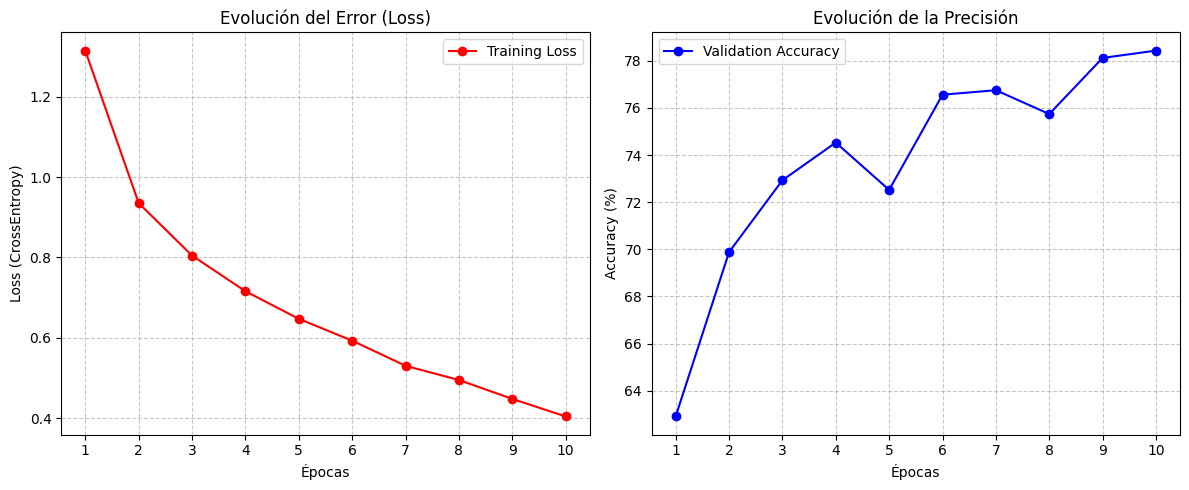

In [11]:
# Crear la figura con dos subgráficos
plt.figure(figsize=(12, 5))

# 1. Gráfico de la Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, marker='o', color='red', label='Training Loss')
plt.title('Evolución del Error (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss (CrossEntropy)')
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 2. Gráfico de la Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), val_accuracies, marker='o', color='blue', label='Validation Accuracy')
plt.title('Evolución de la Precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (%)')
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Mostrar los gráficos
plt.tight_layout()
plt.show()

### **System Diagram**

Insert your system diagram below (image or drawing). It must clearly show:

- Number of convolutional layers  
- Kernel size(s)
- Pooling layers (if any)  
- etc..  

In [17]:
!conda install -y -c conda-forge graphviz

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.



In [12]:
!pip install graphviz

Promnt:

A partir del siguiente código que define la arquitectura de una Red Neuronal Convolucional (CNN), genera un script en Python utilizando la librería graphviz para dibujar el diagrama de flujo de datos del modelo.

**(Inserté el codigo hecho)**

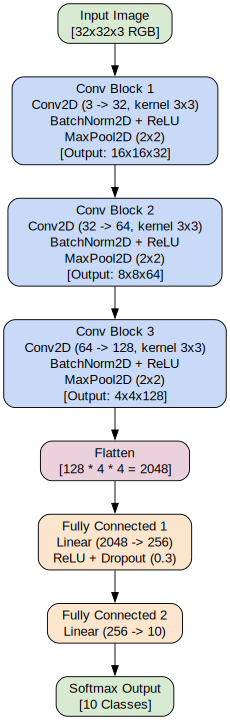

In [ ]:
# Insert or display your system diagram image here
import graphviz

# Crear el objeto de diagrama dirigido
dot = graphviz.Digraph(name='CNN_Architecture', format='png')

# Configuración general de visualización (orientación vertical 'TB' = Top to Bottom)
dot.attr(rankdir='TB', size='8,10', fontname='Helvetica')
dot.attr('node', fontname='Helvetica', shape='box', style='rounded,filled')

# Definir los nodos (las capas) con colores para categorizarlos
# Entrada
dot.node('Input', 'Input Image\n[32x32x3 RGB]', fillcolor='#D9EAD3')

# Bloques Convolucionales
dot.node('Block1', 'Conv Block 1\nConv2D (3 -> 32, kernel 3x3)\nBatchNorm2D + ReLU\nMaxPool2D (2x2)\n[Output: 16x16x32]', fillcolor='#C9DAF8')
dot.node('Block2', 'Conv Block 2\nConv2D (32 -> 64, kernel 3x3)\nBatchNorm2D + ReLU\nMaxPool2D (2x2)\n[Output: 8x8x64]', fillcolor='#C9DAF8')
dot.node('Block3', 'Conv Block 3\nConv2D (64 -> 128, kernel 3x3)\nBatchNorm2D + ReLU\nMaxPool2D (2x2)\n[Output: 4x4x128]', fillcolor='#C9DAF8')

# Aplanado
dot.node('Flatten', 'Flatten\n[128 * 4 * 4 = 2048]', fillcolor='#EAD1DC')

# Capas Fully Connected (Densas)
dot.node('FC1', 'Fully Connected 1\nLinear (2048 -> 256)\nReLU + Dropout (0.3)', fillcolor='#FCE5CD')
dot.node('FC2', 'Fully Connected 2\nLinear (256 -> 10)', fillcolor='#FCE5CD')

# Salida
dot.node('Output', 'Softmax Output\n[10 Classes]', fillcolor='#D9EAD3')

# Conectar los nodos (los bordes/flechas)
dot.edge('Input', 'Block1')
dot.edge('Block1', 'Block2')
dot.edge('Block2', 'Block3')
dot.edge('Block3', 'Flatten')
dot.edge('Flatten', 'FC1')
dot.edge('FC1', 'FC2')
dot.edge('FC2', 'Output')

# Mostrar el diagrama directamente en Jupyter Notebook
dot

### **Written Analysis Questions**

**1. Why increasing depth could improve performance.**

Aumentar la profundidad amplía el campo receptivo y permite que la red aprenda una representación jerárquica de los datos. Las capas iniciales capturan características de bajo nivel (bordes, colores), las capas intermedias capturan texturas y las capas más profundas las componen en conceptos de objetos de alto nivel (por ejemplo, una rueda de coche o la oreja de un perro), mejorando así la capacidad de clasificación.

**2. Under what conditions deeper networks may hurt performance.**

Las redes más profundas pueden perjudicar el rendimiento si no hay suficientes datos (lo que provoca un sobreajuste grave) o si sufren el problema del gradiente de desaparición/explosión, donde los errores no se propagan correctamente a las capas iniciales. Además, introducen problemas de degradación si no se utilizan las conexiones residuales (como en ResNet).
**3. How could dropout, batch normalization, or data augmentation help?**

Normalización por lotes: Suaviza el panorama de pérdidas y acelera el entrenamiento al estandarizar las entradas de las capas.

Dropout: Actúa como regularización al deshabilitar neuronas aleatorias, lo que previene la coadaptación y el sobreajuste.

Aumento de datos: Expande artificialmente el conjunto de datos (p. ej., invirtiendo o recortando imágenes), lo que aumenta la robustez del modelo ante variaciones y evita que memorice muestras de entrenamiento exactas.


**4. How would you determine whether your CNN is overfitting or underfitting?**

Comparando las métricas de entrenamiento y validación/prueba.

Sobreajuste: La precisión del entrenamiento es muy alta (p. ej., 95%), pero la precisión de la validación se estancó o está disminuyendo (p. ej., 65%).

Infraajuste: Tanto la precisión del entrenamiento como la de la validación son bajas, lo que significa que el modelo es demasiado simple para capturar los patrones subyacentes en los datos.

**5. Which architectural components most impact computational cost?**

las capas convolucionales son las que más estresan el procesador o GPU en términos de cómputo (FLOPs) debido a la enorme cantidad de operaciones matemáticas (multiplicaciones de matrices). Por otro lado, las capas Fully Connected (Linear) son las que consumen la mayor parte de la memoria RAM/VRAM, ya que contienen la inmensa mayoría de los parámetros (pesos) del modelo.

**6. Whether the accuracy gain justifies the added complexity in a real-world deployment scenario.**
Depende, intentando que un modelo corra en hardware limitado o como un proceso en segundo plano, una mejora del 2% en precisión podría no justificar triplicar el tiempo de inferencia o el tamaño en MB del modelo. En este caso, podemos ver que el incremento llegó a 78% de accuracy y con un costo de tiempo medianamente bajo, por lo que si sería justificado.

## **Grading Rubric (10 points)**

| Criterion | Points |
|------------|--------|
| **Baseline Reproduction** – Correct implementation and training of the provided baseline CNN. Clear report of baseline accuracy and training setup. | 1 |
| **Architectural Modifications** – Meaningful and technically justified changes to the CNN architecture (e.g., depth, kernel size, normalization, dropout, residual connections). Changes must go beyond trivial parameter tuning. | 2 |
| **Written Architectural Justification** – Clear explanation of *why* the chosen modifications should improve performance (receptive field, feature hierarchy, regularization, gradient flow, etc.). | 2 |
| **Experimental Design & Comparison** – Systematic comparison between baseline and modified model (same dataset split, controlled variables, reported metrics). Includes training/validation accuracy curves. | 2 |
| **Performance Improvement** – Modified architecture surpasses baseline validation/test accuracy. <br>• +1% improvement: 0.5 pts <br>• +2% improvement: 1 pt | 1 |
| **Generalization Analysis** – Discussion of overfitting/underfitting behavior and the role of regularization techniques (BatchNorm, Dropout, data augmentation, etc.). | 1 |
| **Computational Tradeoff Reflection** – Analysis of parameter count, training time, and whether the accuracy gain justifies the added complexity. | 1 |
| **Code Clarity & PyTorch Best Practices** – Clean modular implementation (proper use of `nn.Module`, readable forward pass, reproducibility practices). | 1 |
| **Total** | **10** |

---

### Notes

- Simply increasing the number of filters without justification will not receive full architectural credit.
- Accuracy alone does not guarantee a high grade — reasoning and analysis are weighted heavily.
- Extra credit (+0.5) may be awarded for implementing advanced concepts (e.g., residual blocks, learning rate scheduling experiments, or ablation studies). Applies just for students with <10 points.

---

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>